#  Important Lib

In [1]:
import pandas as pd
import numpy as np

# Read the data

In [2]:
df = pd.read_csv('hr_data.csv')
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.45,0.46,2,130,3,0,1,0,technical,low
1,0.63,0.66,3,256,4,1,0,0,RandD,low
2,0.12,0.47,3,258,5,0,0,0,sales,medium
3,0.89,0.87,5,225,5,0,1,0,product_mng,low
4,0.81,0.95,5,238,6,0,1,0,technical,low
...,...,...,...,...,...,...,...,...,...,...
7166,0.14,0.38,5,115,6,1,0,0,marketing,high
7167,0.84,0.59,3,234,2,0,0,0,sales,medium
7168,0.94,0.74,4,224,5,0,0,0,sales,low
7169,0.83,0.92,4,255,5,0,1,0,accounting,low


# Base Question
# Predict who will stay in organisation
# retention based on the employee data

In [3]:
df['left'].value_counts()

left
0    3600
1    3571
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7171 entries, 0 to 7170
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     7171 non-null   float64
 1   last_evaluation        7171 non-null   float64
 2   number_project         7171 non-null   int64  
 3   average_montly_hours   7171 non-null   int64  
 4   time_spend_company     7171 non-null   int64  
 5   Work_accident          7171 non-null   int64  
 6   left                   7171 non-null   int64  
 7   promotion_last_5years  7171 non-null   int64  
 8   Department             7171 non-null   object 
 9   salary                 7171 non-null   object 
dtypes: float64(2), int64(6), object(2)
memory usage: 560.4+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,7171.0,0.552520,0.268051,0.09,0.38,0.56,0.79,1.0
last_evaluation,7171.0,0.716426,0.181115,0.36,0.54,0.73,0.88,1.0
number_project,7171.0,3.831962,1.460141,2.00,2.00,4.00,5.00,7.0
average_montly_hours,7171.0,203.725143,54.171299,96.00,152.00,205.00,253.00,310.0
time_spend_company,7171.0,3.632129,1.330238,2.00,3.00,3.00,4.00,10.0
Work_accident,7171.0,0.108493,0.311023,0.00,0.00,0.00,0.00,1.0
left,7171.0,0.497978,0.500031,0.00,0.00,0.00,1.00,1.0
promotion_last_5years,7171.0,0.014921,0.121246,0.00,0.00,0.00,0.00,1.0


In [6]:
df[df['left'] == 1]['Work_accident'].value_counts(normalize = True)

Work_accident
0    0.952674
1    0.047326
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

# Correlation

In [8]:
df.corr(numeric_only = True).T

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.127091,-0.173156,-0.067636,-0.000662,0.078308,-0.417742,0.039740
last_evaluation,0.127091,1.000000,0.556541,0.543941,0.301256,-0.018172,0.009276,-0.029010
number_project,-0.173156,0.556541,1.000000,0.636384,0.300916,-0.015130,0.016058,-0.016560
average_montly_hours,-0.067636,0.543941,0.636384,1.000000,0.280071,-0.013246,0.067922,-0.016045
time_spend_company,-0.000662,0.301256,0.300916,0.280071,1.000000,-0.016112,0.182980,0.030579
Work_accident,0.078308,-0.018172,-0.015130,-0.013246,-0.016112,1.000000,-0.195883,0.038432
left,-0.417742,0.009276,0.016058,0.067922,0.182980,-0.195883,1.000000,-0.078868
promotion_last_5years,0.039740,-0.029010,-0.016560,-0.016045,0.030579,0.038432,-0.078868,1.000000


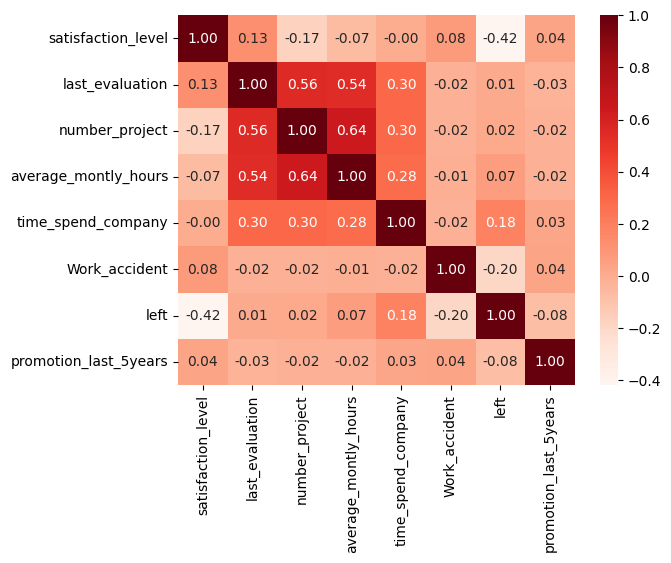

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only = True), cbar = True, cmap = 'Reds', annot = True, fmt = '.2f')
plt.show()

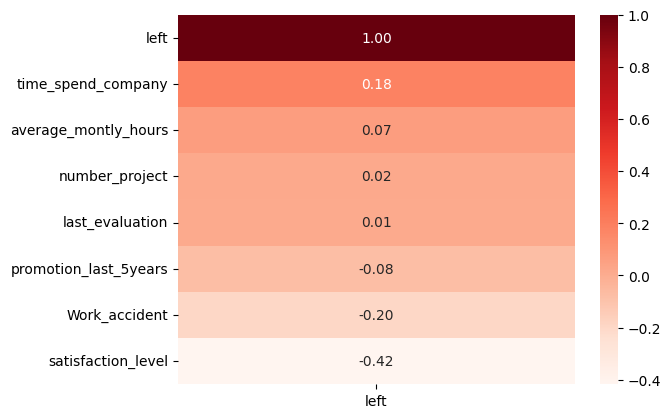

In [10]:
sns.heatmap(df.corr(numeric_only = True)[['left']].sort_values(by ='left', ascending = False),
            cbar = True, cmap = 'Reds', annot = True, fmt = '.2f')
plt.show()

# Visualization

<Axes: xlabel='Department'>

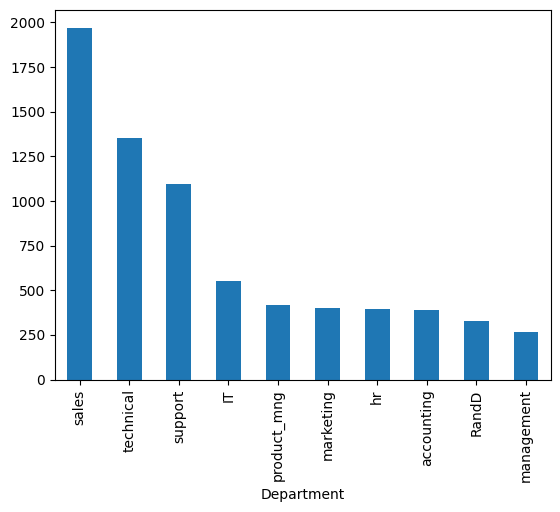

In [11]:
df['Department'].value_counts().plot(kind = 'bar')

In [14]:
df['Department'].value_counts(normalize = True)

Department
sales          0.274857
technical      0.188816
support        0.153117
IT             0.076837
product_mng    0.058290
marketing      0.055641
hr             0.055083
accounting     0.054525
RandD          0.045461
management     0.037373
Name: proportion, dtype: float64

<Axes: xlabel='salary'>

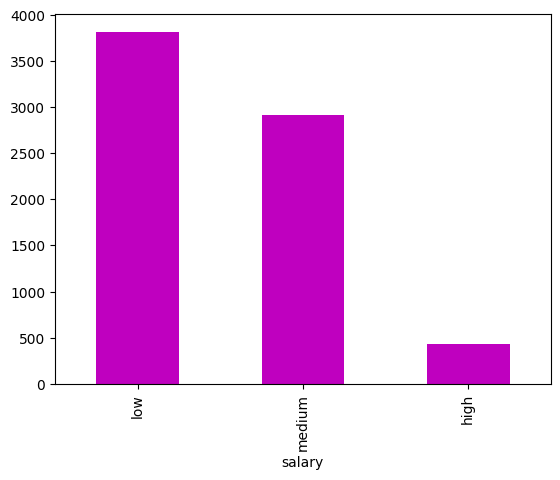

In [15]:
df['salary'].value_counts().plot(kind='bar',color='m')

In [16]:
df['salary'].value_counts(normalize = True)

salary
low       0.532562
medium    0.407196
high      0.060243
Name: proportion, dtype: float64

<Axes: xlabel='left'>

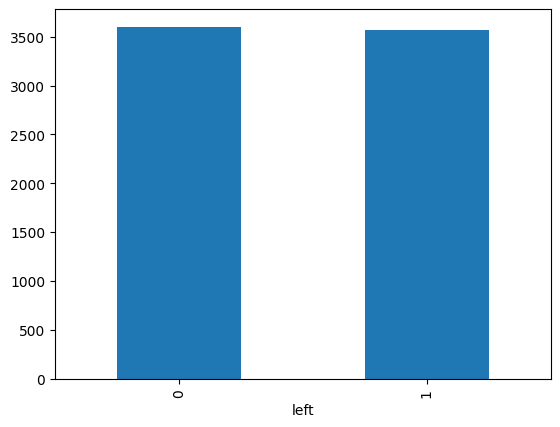

In [17]:
df['left'].value_counts().plot(kind='bar')

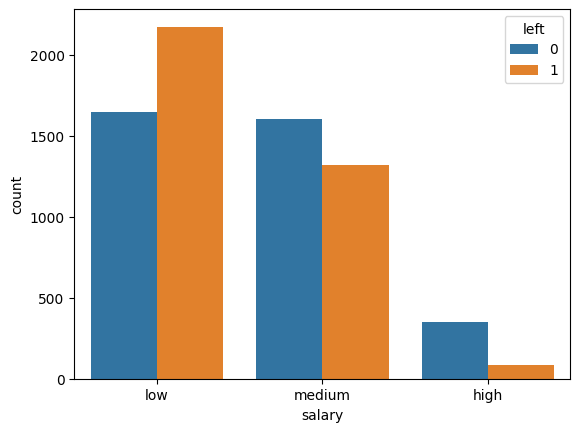

In [18]:
sns.countplot(x = 'salary',hue='left',data=df)
plt.show()

In [19]:
df[df['left']==1]['salary'].value_counts(normalize =True)

salary
low       0.608233
medium    0.368804
high      0.022963
Name: proportion, dtype: float64

In [20]:
df[df['left']==1]['Department'].value_counts(normalize =True)

Department
sales          0.283954
technical      0.195183
support        0.155419
IT             0.076449
hr             0.060207
accounting     0.057127
marketing      0.056847
product_mng    0.055447
RandD          0.033884
management     0.025483
Name: proportion, dtype: float64

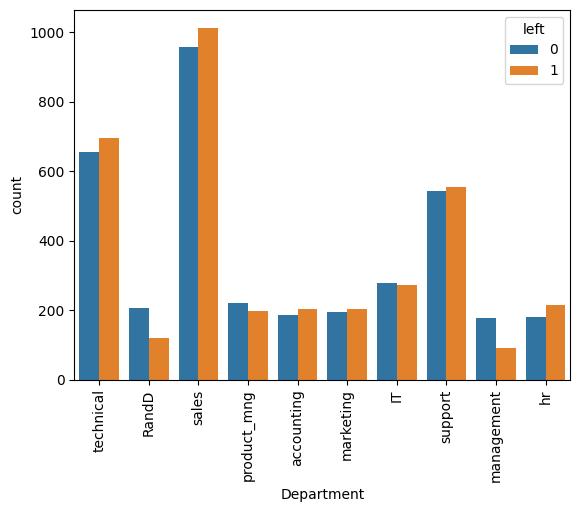

In [23]:
sns.countplot(x = df['Department'].sort_values(),hue='left',data=df)
plt.xticks(rotation=90)
plt.show()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7171 entries, 0 to 7170
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     7171 non-null   float64
 1   last_evaluation        7171 non-null   float64
 2   number_project         7171 non-null   int64  
 3   average_montly_hours   7171 non-null   int64  
 4   time_spend_company     7171 non-null   int64  
 5   Work_accident          7171 non-null   int64  
 6   left                   7171 non-null   int64  
 7   promotion_last_5years  7171 non-null   int64  
 8   Department             7171 non-null   object 
 9   salary                 7171 non-null   object 
dtypes: float64(2), int64(6), object(2)
memory usage: 560.4+ KB


In [25]:
df['Department'].nunique()

10

In [26]:
df['salary'].nunique()

3

In [27]:
df['salary'].head(15)

0        low
1        low
2     medium
3        low
4        low
5       high
6       high
7     medium
8     medium
9        low
10    medium
11       low
12       low
13       low
14       low
Name: salary, dtype: object

# Encoding

In [28]:
# sample code to understand encoding
d = {'Age':[25,36,28,20,19,32,21], 'gender': ['m', 'f','f','m','f','m','f'],
     'job':['a', 'b', 'c', 'a','a','c','a'], 'qut':[10,25,14,32,58,12,14], 'price':[10,25,10,5,9,7,30]}
d1 = pd.DataFrame(d)
d1
# # d1.info()
# Method 1 for encoding Manual (map)
d1['gender_num'] = d1['gender'].map({'m':1, 'f':0})
# Method 2 for encoding Manual (apply)
def job_fun(x):
    if x=='a':
        return 1
    elif x=='b':
        return 2
    else:
        return 3
d1['job_num'] = d1['job'].apply(job_fun)
d1

# d1['Male_Yes'] = d1['gender'].map({'m':True, 'f':False})
# d1
# d1['Female_Yes'] = d1['gender'].map({'m':False, 'f':True})
# d1
# d1['amount'] = d1['qut']*d1['price']
d1


,Age,gender,job,qut,price,gender_num,job_num
0,25,m,a,10,10,1,1
1,36,f,b,25,25,0,2
2,28,f,c,14,10,0,3
3,20,m,a,32,5,1,1
4,19,f,a,58,9,0,1
5,32,m,c,12,7,1,3
6,21,f,a,14,30,0,1


In [29]:
feature_eng = pd.get_dummies(columns=['salary'], data=df,drop_first= False, dtype = 'int')
feature_eng.head(15)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary_high,salary_low,salary_medium
0,0.45,0.46,2,130,3,0,1,0,technical,0,1,0
1,0.63,0.66,3,256,4,1,0,0,RandD,0,1,0
2,0.12,0.47,3,258,5,0,0,0,sales,0,0,1
3,0.89,0.87,5,225,5,0,1,0,product_mng,0,1,0
4,0.81,0.95,5,238,6,0,1,0,technical,0,1,0
5,0.86,0.82,3,263,6,0,0,0,sales,1,0,0
6,0.97,0.55,4,166,3,1,0,0,accounting,1,0,0
7,0.37,0.47,2,151,3,0,1,0,sales,0,0,1
8,0.96,0.54,3,153,2,0,0,0,technical,0,0,1
9,0.48,0.98,5,132,4,0,0,0,sales,0,1,0


In [30]:
df['Department'].unique()

array(['technical', 'RandD', 'sales', 'product_mng', 'accounting',
       'marketing', 'IT', 'support', 'management', 'hr'], dtype=object)

In [31]:
df.shape

(7171, 10)

In [32]:
newdf = pd.get_dummies(columns=['salary', 'Department'], data=df,drop_first= True, dtype = int)
newdf.sample(15)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_low,salary_medium,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
3905,0.10,0.90,6,301,5,0,1,0,1,0,0,0,0,0,0,0,0,0,1
1100,0.09,0.85,6,289,4,0,1,0,0,0,0,0,1,0,0,0,0,0,0
3629,0.94,0.71,3,175,3,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4496,0.11,0.91,6,308,4,1,1,0,1,0,0,0,0,0,0,0,0,0,0
3172,0.56,0.78,4,193,2,1,0,0,1,0,0,0,0,0,0,0,0,1,0
3688,0.36,0.54,2,158,3,0,1,0,1,0,0,0,0,0,0,0,0,1,0
1533,0.45,0.51,2,137,3,0,1,0,1,0,0,0,0,0,0,0,0,1,0
5966,0.57,0.67,3,138,6,1,0,0,0,1,0,0,0,0,0,0,0,0,0
4713,0.90,0.98,5,243,6,0,1,0,1,0,0,0,0,0,1,0,0,0,0
5829,0.11,0.78,7,278,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [33]:
newdf.shape

(7171, 19)

# Divide the data into X(Independent) and Y(Dependent)

<Axes: >

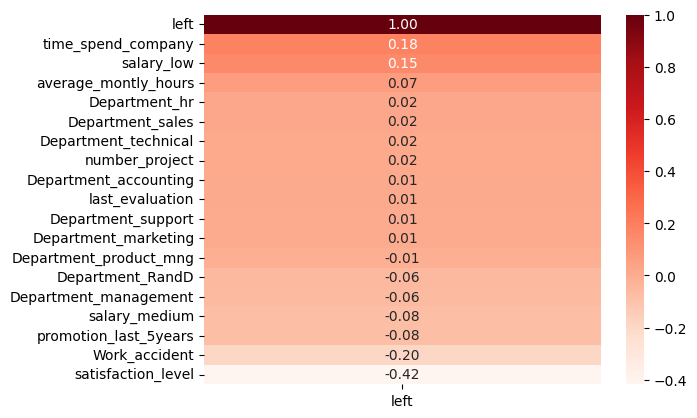

In [34]:
sns.heatmap(newdf.corr()[['left']].sort_values(by= 'left', ascending = False), cmap = 'Reds', annot = True, fmt = '.2f' )

In [35]:
newdf.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,7171.0,0.552520,0.268051,0.09,0.38,0.56,0.79,1.0
last_evaluation,7171.0,0.716426,0.181115,0.36,0.54,0.73,0.88,1.0
number_project,7171.0,3.831962,1.460141,2.00,2.00,4.00,5.00,7.0
average_montly_hours,7171.0,203.725143,54.171299,96.00,152.00,205.00,253.00,310.0
time_spend_company,7171.0,3.632129,1.330238,2.00,3.00,3.00,4.00,10.0
Work_accident,7171.0,0.108493,0.311023,0.00,0.00,0.00,0.00,1.0
left,7171.0,0.497978,0.500031,0.00,0.00,0.00,1.00,1.0
promotion_last_5years,7171.0,0.014921,0.121246,0.00,0.00,0.00,0.00,1.0
salary_low,7171.0,0.532562,0.498973,0.00,0.00,1.00,1.00,1.0
salary_medium,7171.0,0.407196,0.491346,0.00,0.00,0.00,1.00,1.0


In [36]:
newdf.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_low,salary_medium,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.45,0.46,2,130,3,0,1,0,1,0,0,0,0,0,0,0,0,0,1
1,0.63,0.66,3,256,4,1,0,0,1,0,1,0,0,0,0,0,0,0,0
2,0.12,0.47,3,258,5,0,0,0,0,1,0,0,0,0,0,0,1,0,0
3,0.89,0.87,5,225,5,0,1,0,1,0,0,0,0,0,0,1,0,0,0
4,0.81,0.95,5,238,6,0,1,0,1,0,0,0,0,0,0,0,0,0,1


In [37]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [38]:
# f1      f2      y       f2_c
# 0       100     1       0.1
# 1       600     0       0.6
# 0       200     1       0.2
# 1       50      1       0.05
# 0       1000    0       1
# 0       800     0       0.8
# 1       400     1       0.4


# Normalization in machine learning is the process of translating data into the range [0, 1] (or any other range) or simply transforming data onto the unit sphere.


# **What is Feature Scaling?**
# Feature scaling is a data preprocessing technique used to transform the values of features or variables in a dataset to a similar scale. The purpose is to ensure that all features contribute equally to the model and to avoid the domination of features with larger values.

# **What Is Normalization?**
Normalization is a data preprocessing technique used to adjust the values of features in a dataset to a common scale. This is done to facilitate data analysis and modeling, and to reduce the impact of different scales on the accuracy of machine learning models.

Normalization is a scaling technique in which values are shifted and rescaled so that they end up ranging between 0 and 1. It is also known as Min-Max scaling.

Here’s the formula for normalization:

Normalization equation

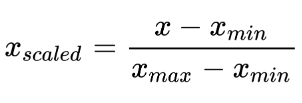

In [39]:
def normalization(x):
    y = []
    for i in range(len(x)):
        y.append((x[i]-min(x))/(max(x)-min(x)))
    return y

In [40]:
li = [1,40,50,10,80,60,5]
res = normalization(li)
res

[0.0,
 0.4936708860759494,
 0.620253164556962,
 0.11392405063291139,
 1.0,
 0.7468354430379747,
 0.05063291139240506]

# **What Is Standardization?**
Standardization is another scaling method where the values are centered around the mean with a unit standard deviation. This means that the mean of the attribute becomes zero, and the resultant distribution has a unit standard deviation.

Here’s the formula for standardization:

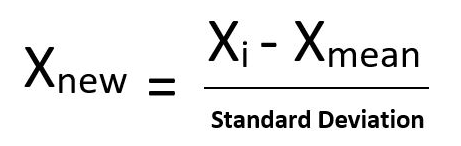

# Separate the X and Y

In [41]:
# Dependent Values
y = newdf['left']
# Independent Values
x = newdf.drop('left', axis = 1)

In [45]:
# Split the data into trian and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size = 0.8,
                                                    random_state=9785,
                                                    stratify= y)

In [46]:
print('x_train = ',x_train.shape)
print('x_test = ', x_test.shape)

x_train =  (5736, 18)
x_test =  (1435, 18)


In [47]:
y_train.shape

(5736,)

In [48]:
y_train.value_counts(normalize = True)

left
0    0.502092
1    0.497908
Name: proportion, dtype: float64

In [49]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [50]:
x_train

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_low,salary_medium,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
3428,0.83,0.94,4,264,5,0,0,1,0,0,0,0,0,0,0,1,0,0
4862,0.77,0.98,4,238,6,0,0,1,0,0,0,0,0,0,0,0,1,0
3441,0.66,0.67,3,123,4,0,0,0,1,0,0,0,0,0,0,0,0,0
6288,0.86,1.00,5,257,5,0,0,0,1,0,0,0,0,0,0,0,0,1
4599,0.70,0.60,5,208,3,0,0,0,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,0.75,0.41,5,196,4,0,0,1,0,0,0,0,0,0,0,1,0,0
6846,0.62,0.91,3,251,10,0,0,0,1,0,0,0,0,0,0,1,0,0
1698,0.37,0.46,2,130,3,1,0,0,1,0,0,0,0,0,0,0,0,1
3484,0.77,0.98,5,259,6,0,0,1,0,0,0,0,0,0,1,0,0,0


In [51]:
x_train_sc = sc.fit_transform(x_train)

In [52]:
x_train_sc

array([[ 1.0377628 ,  1.23923045,  0.11224307, ...,  1.63613052,
        -0.42111744, -0.48491455],
       [ 0.81352957,  1.45984749,  0.11224307, ..., -0.61119818,
         2.37463447, -0.48491455],
       [ 0.40243532, -0.24993457, -0.57122429, ..., -0.61119818,
        -0.42111744, -0.48491455],
       ...,
       [-0.68135862, -1.40817403, -1.25469166, ..., -0.61119818,
        -0.42111744,  2.06221901],
       [ 0.81352957,  1.45984749,  0.79571043, ..., -0.61119818,
        -0.42111744, -0.48491455],
       [-0.41975319, -1.29786551, -1.25469166, ..., -0.61119818,
        -0.42111744,  2.06221901]], shape=(5736, 18))

In [53]:
x_train_sc[0]

array([ 1.0377628 ,  1.23923045,  0.11224307,  1.10320048,  1.02655355,
       -0.34812128, -0.12117124,  0.93449742, -0.82769341, -0.22268428,
       -0.24226689, -0.24547664, -0.19828948, -0.24347439, -0.24786281,
        1.63613052, -0.42111744, -0.48491455])

In [54]:
# x_train.loc[[1493]]

In [55]:
sc.inverse_transform([x_train_sc[0]])

array([[  0.83,   0.94,   4.  , 264.  ,   5.  ,   0.  ,   0.  ,   1.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   1.  ,
          0.  ,   0.  ]])

In [56]:
x_train

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_low,salary_medium,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
3428,0.83,0.94,4,264,5,0,0,1,0,0,0,0,0,0,0,1,0,0
4862,0.77,0.98,4,238,6,0,0,1,0,0,0,0,0,0,0,0,1,0
3441,0.66,0.67,3,123,4,0,0,0,1,0,0,0,0,0,0,0,0,0
6288,0.86,1.00,5,257,5,0,0,0,1,0,0,0,0,0,0,0,0,1
4599,0.70,0.60,5,208,3,0,0,0,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,0.75,0.41,5,196,4,0,0,1,0,0,0,0,0,0,0,1,0,0
6846,0.62,0.91,3,251,10,0,0,0,1,0,0,0,0,0,0,1,0,0
1698,0.37,0.46,2,130,3,1,0,0,1,0,0,0,0,0,0,0,0,1
3484,0.77,0.98,5,259,6,0,0,1,0,0,0,0,0,0,1,0,0,0


In [57]:
x_train_sc[0]

array([ 1.0377628 ,  1.23923045,  0.11224307,  1.10320048,  1.02655355,
       -0.34812128, -0.12117124,  0.93449742, -0.82769341, -0.22268428,
       -0.24226689, -0.24547664, -0.19828948, -0.24347439, -0.24786281,
        1.63613052, -0.42111744, -0.48491455])

In [58]:
x_test_sc = sc.transform(x_test)
x_test_sc

array([[ 0.92564618,  1.29438471, -0.57122429, ..., -0.61119818,
        -0.42111744, -0.48491455],
       [ 1.67309028,  0.68768785, -0.57122429, ..., -0.61119818,
        -0.42111744, -0.48491455],
       [-0.41975319, -1.18755699, -1.25469166, ..., -0.61119818,
        -0.42111744, -0.48491455],
       ...,
       [-0.4944976 , -0.80147717, -1.25469166, ..., -0.61119818,
        -0.42111744, -0.48491455],
       [ 0.81352957,  1.12892193,  0.79571043, ..., -0.61119818,
        -0.42111744, -0.48491455],
       [-1.65303594,  0.79799637,  1.4791778 , ..., -0.61119818,
         2.37463447, -0.48491455]], shape=(1435, 18))

# Data preprocessing is done now model training

In [59]:
# Import of Model
from sklearn.linear_model import LogisticRegression

In [60]:
# model Building with parameter
# model_lg = LogisticRegression(class_weight = 'balanced')
model_lg = LogisticRegression()

In [61]:
import time
st = time.time()
# Model Training (provide data to model object)
model_lg.fit(x_train_sc, y_train)
print('Run time  =',time.time()-st)

Run time  = 0.04169631004333496


In [62]:
# Now predict the values
y_pred_lg = model_lg.predict(x_test_sc)
len(y_pred_lg)

1435

In [63]:
src = pd.Series(y_pred_lg)
src.value_counts(normalize = True)

1    0.516376
0    0.483624
Name: proportion, dtype: float64

In [64]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [65]:
# Model Accuracy Score (Training Score)
model_lg.score(x_train_sc,y_train)

0.7691771269177127

In [66]:
# Accuracy Score (Testing Score)
accuracy_score(y_test, y_pred_lg)

0.7672473867595819

# Confusion Matrix

In [175]:
confusion_matrix(y_test, y_pred_lg)

array([[540, 180],
       [154, 561]])

<Axes: >

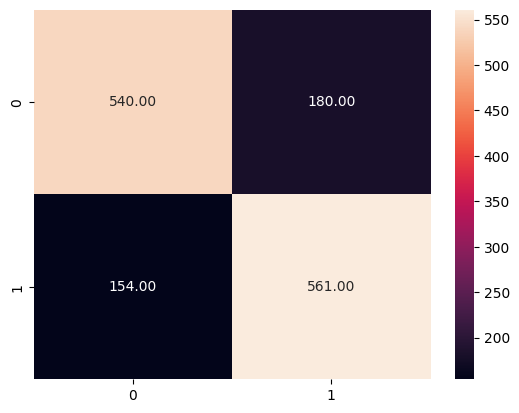

In [176]:
sns.heatmap(confusion_matrix(y_test, y_pred_lg), annot = True, fmt = '.2f')

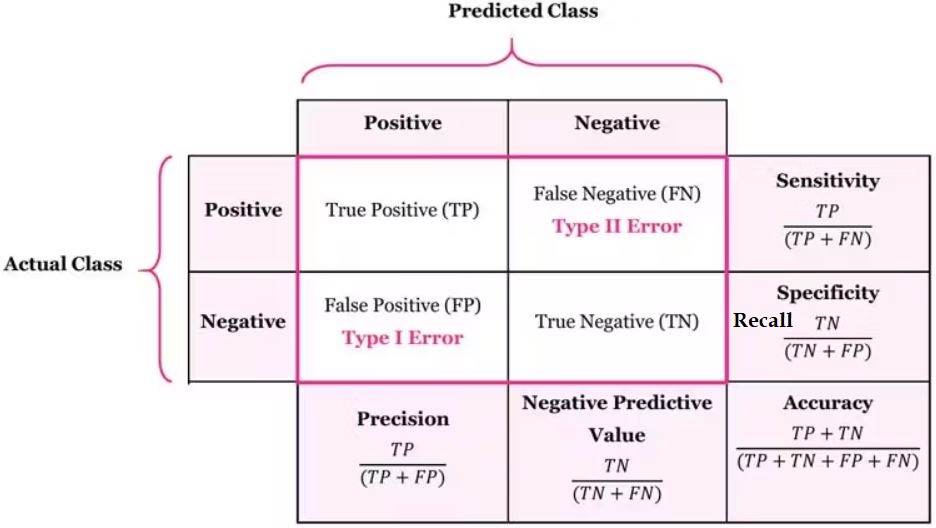

In [177]:
print(classification_report(y_test, y_pred_lg))

              precision    recall  f1-score   support

           0       0.78      0.75      0.76       720
           1       0.76      0.78      0.77       715

    accuracy                           0.77      1435
   macro avg       0.77      0.77      0.77      1435
weighted avg       0.77      0.77      0.77      1435



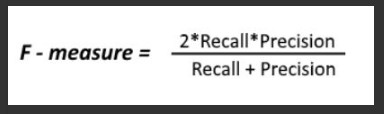

```
🎯 𝐀𝐜𝐜𝐮𝐫𝐚𝐜𝐲:
→ Tells you the proportion of correctly classified instances among all instances.
→ Not suitable for imbalanced datasets because it can be misleading.

💡 𝐏𝐫𝐞𝐜𝐢𝐬𝐢𝐨𝐧:
→ It measures the proportion of true positives among all positive predictions.
→ High Precision is important in scenarios where false positives are undesirable.
→ It helps answer the question: "Of all the instances predicted as positive, how many are actually positive?"

📊 𝐑𝐞𝐜𝐚𝐥𝐥:
→ It calculates the proportion of true positives among all actual positives.
→ Also known as sensitivity or true positive rate
→ High Recall is important in scenarios where false negatives are undesirable.
→ It helps answers the question: "Of all the actual positive instances, how many did we correctly identify?"

📐 𝐅1 𝐒𝐜𝐨𝐫𝐞:
→ Harmonic mean of precision and recall.
→ Takes into account both precision and recall, giving you a single metric that balances the two.
```


In [ ]:
df

In [ ]:
df1 = df[df['left'] ==0].sample(3600).reset_index()
df1

In [ ]:
df1.drop('index', axis = 1, inplace = True)

In [ ]:
df1

In [ ]:
df2 = df[df['left'] ==1].reset_index()
df2

In [ ]:
df2.drop('index', axis = 1, inplace = True)
df2

In [ ]:
bal_df = pd.concat([df1, df2], axis = 0)
bal_df = bal_df.sample(7171).reset_index()
bal_df.drop('index', axis = 1, inplace = True)
bal_df

In [ ]:
bal_df['left'].value_counts()

In [ ]:
bal_df.to_csv('bal_hr_data.csv')

In [ ]:
1e-4